# 02 — Cloud Masking, Normalization, Vegetation Indices, Field Clipping
Turns the raw aligned 10-band cubes from `00_data_acquisition.ipynb` into clean,
model-ready 15-channel cubes:

```
Satellite image
       +
Cloud mask
       ↓
Clean image  →  vegetation indices  →  train-only normalization  →  model input
```

Order used here (slightly reordered from a flat list, for a reason explained below):

1. **Define the field boundary and clip** — so roads/buildings/water never enter the pipeline
2. **Cloud mask** via the Scene Classification (SCL) band — bad pixels → `NaN`
3. **Vegetation indices** (NDVI, NDMI, NDRE, NDWI, SAVI) on the *clean* image only
4. **Normalize** — z-score using statistics from the **training dates only**
5. **Visualize** — RGB / NDVI / NDMI / NDRE per date, mean NDVI & NDMI vs. date

> **Why clip first?** Cloud fraction, band statistics, and index values are all
> sensitive to what's included in the image. If we compute them before clipping,
> a lake or a road in the corner of the tile can skew every downstream number
> (cloud %, normalization mean/std, mean NDVI). Clip first, then everything else
> is computed only over pixels that are actually crop.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import json
from shapely.geometry import box, mapping

from preprocessing import (
    SENTINEL2_BANDS, apply_cloud_mask, resample_band_to_reference,
    clip_raster_to_boundary, compute_channel_stats, standardize_channels,
    save_norm_stats, load_norm_stats,
)
from features import stack_15_channels, INDEX_NAMES_15CH

FIELD_ID = "field_001"
ALIGNED_DIR = f"../data/raw/sentinel2/{FIELD_ID}"
NATIVE_DIR = f"../data/raw/sentinel2_native/{FIELD_ID}"
PROCESSED_DIR = f"../data/processed/{FIELD_ID}"
os.makedirs(PROCESSED_DIR, exist_ok=True)

dates = sorted(d.replace(".tif", "") for d in os.listdir(ALIGNED_DIR) if d.endswith(".tif"))
print(f"{len(dates)} dates:", dates)

CHANNEL_NAMES = SENTINEL2_BANDS + list(INDEX_NAMES_15CH)
print(f"{len(CHANNEL_NAMES)} output channels:", CHANNEL_NAMES)


6 dates: ['2024-06-01', '2024-06-08', '2024-06-15', '2024-06-22', '2024-06-29', '2024-07-06']
15 output channels: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDMI', 'NDRE', 'NDWI', 'SAVI']


## Step 9 — Define the field boundary and clip
In production, load a real digitized field polygon (from QGIS, a farm-management platform, or a cadastral/parcel dataset). Here, since this is synthetic data with no real parcel file, we define a boundary that insets ~8% from the scene edge — standing in for excluding a border road / adjacent field. **Replace `field_geom` with a real polygon read via `geopandas.read_file(...)` when you have one.**

In [2]:
sample_tif = os.path.join(ALIGNED_DIR, f"{dates[0]}.tif")
with rasterio.open(sample_tif) as src:
    bounds, raster_crs = src.bounds, src.crs

margin_frac = 0.08
dx = (bounds.right - bounds.left) * margin_frac
dy = (bounds.top - bounds.bottom) * margin_frac
field_geom = box(bounds.left + dx, bounds.bottom + dy, bounds.right - dx, bounds.top - dy)

boundary_path = f"../data/labels/{FIELD_ID}_boundary.geojson"
with open(boundary_path, "w") as f:
    json.dump({"type": "FeatureCollection",
               "features": [{"type": "Feature", "properties": {}, "geometry": mapping(field_geom)}]}, f)

print("field boundary saved to", boundary_path)
print("boundary bounds:", field_geom.bounds, " | scene bounds:", tuple(bounds))


field boundary saved to ../data/labels/field_001_boundary.geojson
boundary bounds: (753204.8, 1189644.8, 755355.2, 1191795.2)  | scene bounds: (753000.0, 1189440.0, 755560.0, 1192000.0)


### (Demo only) inject a synthetic cloud event
So Step 1 (cloud masking) has something real to mask, we add a cloud patch to the **June 29** SCL band in a different location than the genuine crop-stress patch baked into the synthetic data — this lets us show, side by side, that a cloud-covered pixel (→ masked to NaN) is *not* the same thing as a genuinely stressed pixel (→ a real low NDVI value). Delete this cell entirely when working with real Sentinel-2 SCL data.

In [3]:
CLOUD_DEMO_DATE = "2024-06-29"
scl_path = os.path.join(NATIVE_DIR, CLOUD_DEMO_DATE, "SCL.tif")

with rasterio.open(scl_path) as src:
    scl = src.read(1)
    profile = src.profile

h, w = scl.shape
# place the synthetic cloud in the opposite corner from the vegetation-stress patch
scl[int(h * 0.55):, int(w * 0.55):] = 9  # SCL class 9 = cloud, high probability

with rasterio.open(scl_path, "w", **profile) as dst:
    dst.write(scl, 1)

print(f"injected a synthetic cloud block into {CLOUD_DEMO_DATE} SCL band "
      f"({(scl == 9).sum()} px, {100*(scl==9).mean():.1f}% of scene)")


injected a synthetic cloud block into 2024-06-29 SCL band (3364 px, 20.5% of scene)


## Step 1 — Cloud mask, then clip, per date
For every date: resample SCL to the 10 m grid (nearest-neighbor — it's categorical), clip both the band cube and SCL to the field boundary, then mask invalid SCL classes to `NaN` across all channels **before** any index math.

In [4]:
from rasterio.warp import Resampling as WarpResampling

def load_and_clean(date_str, boundary_geoms):
    native_dir = os.path.join(NATIVE_DIR, date_str)
    aligned_tif = os.path.join(ALIGNED_DIR, f"{date_str}.tif")

    # 1a. resample SCL (native 20 m, categorical) onto the same 10 m grid as the band cube
    scl_10m_path = os.path.join(native_dir, "SCL_10m.tif")
    resample_band_to_reference(
        os.path.join(native_dir, "SCL.tif"), aligned_tif, scl_10m_path,
        resampling=WarpResampling.nearest,
    )

    # 1b. clip the 10-band cube and the SCL band to the field boundary
    cube, cube_profile = clip_raster_to_boundary(aligned_tif, boundary_geoms)
    scl_clipped, _ = clip_raster_to_boundary(scl_10m_path, boundary_geoms, nodata=0)
    scl_clipped = scl_clipped[0]  # (1,H,W) -> (H,W)

    # 1c. cloud mask: bad pixels -> NaN, across every channel
    clean_cube, valid_mask = apply_cloud_mask(cube, scl_clipped)

    return clean_cube, valid_mask, cube_profile


clean_cubes, valid_masks, profiles = {}, {}, {}
for date_str in dates:
    clean_cube, valid_mask, profile = load_and_clean(date_str, [field_geom])
    clean_cubes[date_str] = clean_cube
    valid_masks[date_str] = valid_mask
    profiles[date_str] = profile
    pct_valid = 100 * valid_mask.mean()
    print(f"{date_str}: clipped shape {clean_cube.shape}, {pct_valid:.1f}% valid (cloud-free & in-field) pixels")


2024-06-01: clipped shape (10, 216, 216), 100.0% valid (cloud-free & in-field) pixels


2024-06-08: clipped shape (10, 216, 216), 100.0% valid (cloud-free & in-field) pixels


2024-06-15: clipped shape (10, 216, 216), 100.0% valid (cloud-free & in-field) pixels


2024-06-22: clipped shape (10, 216, 216), 100.0% valid (cloud-free & in-field) pixels


2024-06-29: clipped shape (10, 216, 216), 80.2% valid (cloud-free & in-field) pixels
2024-07-06: clipped shape (10, 216, 216), 100.0% valid (cloud-free & in-field) pixels


## Step 2 — Vegetation indices (on the clean image only)
Stack NDVI, NDMI, NDRE, NDWI, SAVI onto the 10 clipped/masked bands → **15 channels**. NaNs from the cloud mask propagate through the index math automatically, so cloud pixels stay `NaN` in every derived channel too — they never get a fabricated index value.

In [5]:
channel_cubes = {}
for date_str, cube in clean_cubes.items():
    channel_cubes[date_str] = stack_15_channels(cube)  # (10,H,W) -> (15,H,W)

h, w = channel_cubes[dates[0]].shape[1:]
print(f"per-date cube shape: {len(CHANNEL_NAMES)} x {h} x {w}  (Height x Width x 15 in HWC terms: {h} x {w} x 15)")


per-date cube shape: 15 x 216 x 216  (Height x Width x 15 in HWC terms: 216 x 216 x 15)


## Step 3 — Normalize using TRAINING dates only
Split by date (this is a time series — later dates are the ones we ultimately want to generalize to), compute per-channel mean/std from the **train** split only, and apply that same transform everywhere. **Validation/test statistics must never leak into these numbers.**

In [6]:
TRAIN_DATES = dates[:4]   # June 1, 8, 15, 22
VAL_DATE    = dates[4]    # June 29  (contains the synthetic cloud patch)
TEST_DATE   = dates[5]    # July 6   (contains the genuine stress patch)
print("train:", TRAIN_DATES, "| val:", VAL_DATE, "| test:", TEST_DATE)

train_scenes = [channel_cubes[d] for d in TRAIN_DATES]
mean, std = compute_channel_stats(train_scenes)   # NaNs (cloud/out-of-field) ignored automatically

stats_path = os.path.join(PROCESSED_DIR, "norm_stats.npz")
save_norm_stats(mean, std, stats_path)

stats_df = pd.DataFrame({"channel": CHANNEL_NAMES, "mean": mean, "std": std}).set_index("channel")
stats_df


train: ['2024-06-01', '2024-06-08', '2024-06-15', '2024-06-22'] | val: 2024-06-29 | test: 2024-07-06


,mean,std
channel,,
B02,741.015686,138.425491
B03,741.015686,138.425491
B04,1153.557007,267.186676
B05,1474.742432,340.395660
B06,1474.742432,340.395660
B07,1474.742432,340.395660
B08,2466.966064,454.966675
B8A,2542.352783,622.969299
B11,1714.599487,388.599518


In [7]:
normalized_cubes = {d: standardize_channels(c, mean, std) for d, c in channel_cubes.items()}

for d in dates:
    c = normalized_cubes[d]
    valid = ~np.isnan(c[0])
    print(f"{d}: post-normalization mean~0 check -> "
          f"{np.nanmean(c[:, valid]):.3f} (should be near 0 for train dates, may drift for val/test)")


2024-06-01: post-normalization mean~0 check -> -0.055 (should be near 0 for train dates, may drift for val/test)
2024-06-08: post-normalization mean~0 check -> -0.299 (should be near 0 for train dates, may drift for val/test)
2024-06-15: post-normalization mean~0 check -> 0.002 (should be near 0 for train dates, may drift for val/test)
2024-06-22: post-normalization mean~0 check -> 0.352 (should be near 0 for train dates, may drift for val/test)
2024-06-29: post-normalization mean~0 check -> 0.308 (should be near 0 for train dates, may drift for val/test)
2024-07-06: post-normalization mean~0 check -> 0.329 (should be near 0 for train dates, may drift for val/test)


## Save the processed cubes
One `.npy` per date, 15 channels, plus the normalization stats and channel names — everything downstream notebooks need.

In [8]:
for date_str, cube in normalized_cubes.items():
    np.save(os.path.join(PROCESSED_DIR, f"clean_channels_{date_str}.npy"), cube.astype(np.float32))

with open(os.path.join(PROCESSED_DIR, "channel_names.json"), "w") as f:
    json.dump(CHANNEL_NAMES, f)
with open(os.path.join(PROCESSED_DIR, "splits.json"), "w") as f:
    json.dump({"train": TRAIN_DATES, "val": VAL_DATE, "test": TEST_DATE}, f)

print("saved", len(normalized_cubes), "clean 15-channel cubes to", PROCESSED_DIR)


saved 6 clean 15-channel cubes to ../data/processed/field_001


## Step 4 — Visualize: RGB, NDVI, NDMI, NDRE per date
Before training anything: look at it. The cloud patch on June 29 should show up as a blank/NaN block, while the genuine stress patch (built into the synthetic data, intensifying toward July 6) should show up as a real, low NDVI/NDRE value — **not** a missing-data hole.

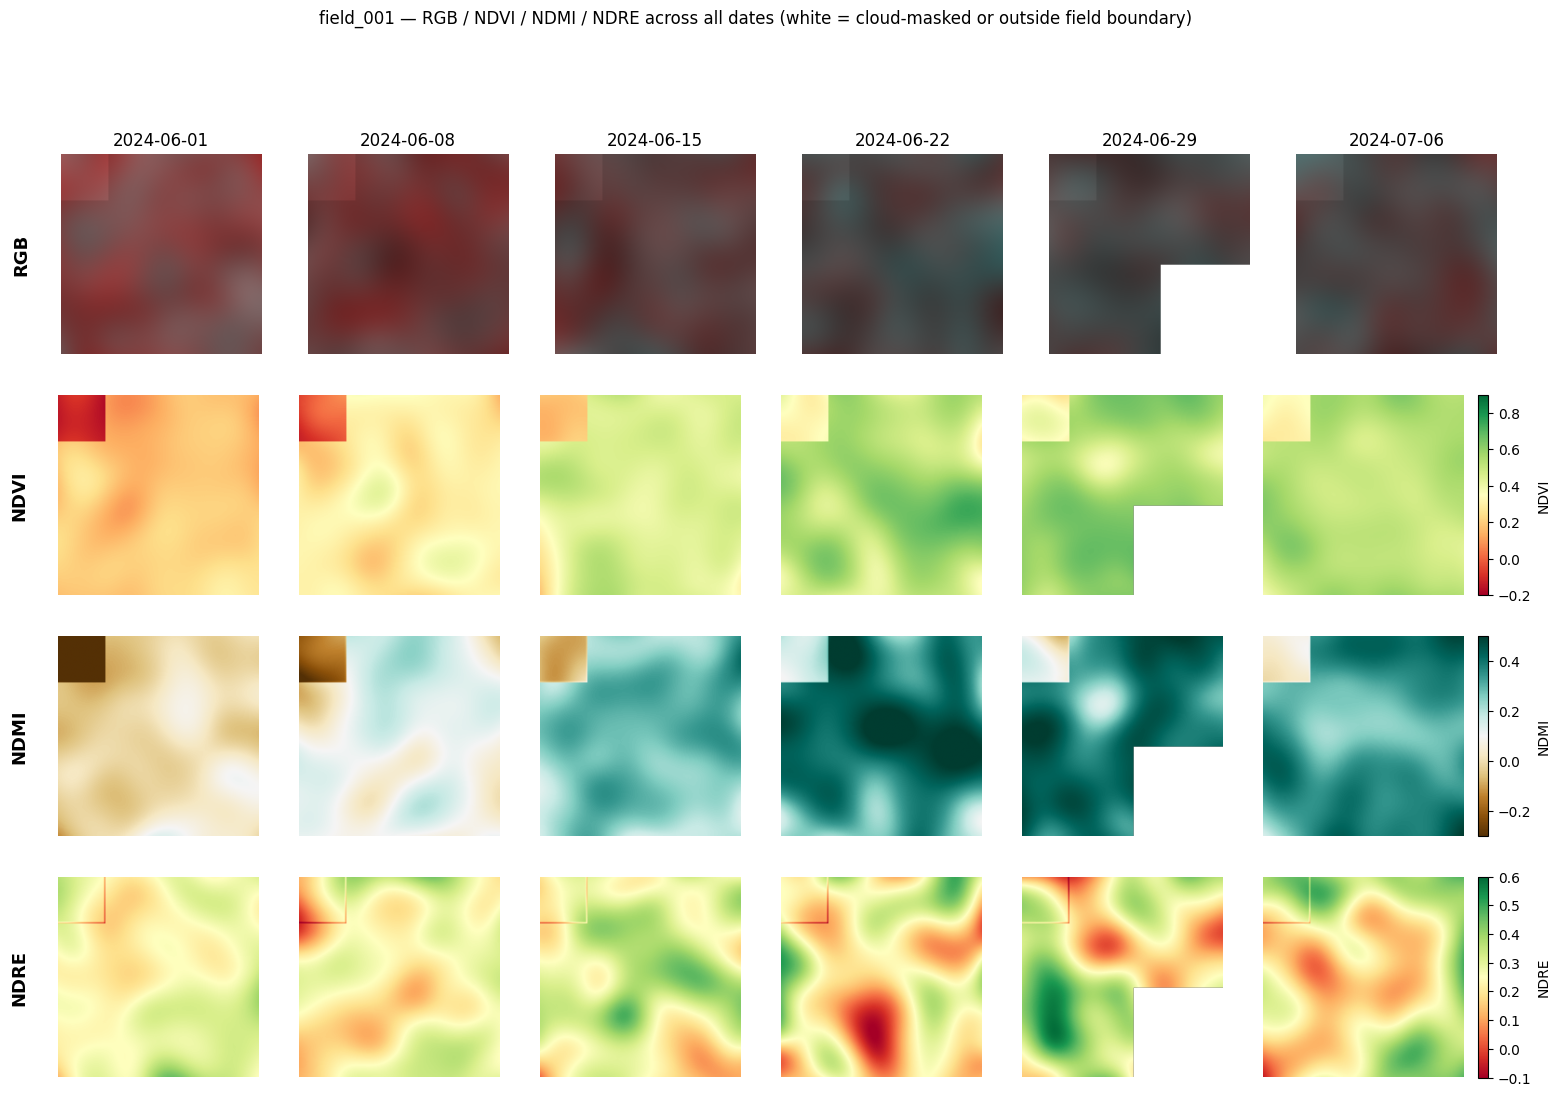

In [9]:
def band_idx(name):
    return CHANNEL_NAMES.index(name)

fig, axes = plt.subplots(4, len(dates), figsize=(3.1 * len(dates), 12))

for col, date_str in enumerate(dates):
    cube = channel_cubes[date_str]  # use pre-normalization values for natural-looking RGB/index display

    r, g, b = cube[band_idx("B04")], cube[band_idx("B03")], cube[band_idx("B02")]
    rgb = np.stack([r, g, b], axis=-1)
    rgb = np.clip(np.nan_to_num(rgb, nan=0) / 3000, 0, 1)
    # show cloud/clip-masked pixels as white in the RGB panel
    invalid = np.isnan(cube[0])
    rgb[invalid] = 1.0

    ndvi_map = cube[band_idx("NDVI")]
    ndmi_map = cube[band_idx("NDMI")]
    ndre_map = cube[band_idx("NDRE")]

    axes[0, col].imshow(rgb); axes[0, col].set_title(date_str)
    im1 = axes[1, col].imshow(ndvi_map, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
    im2 = axes[2, col].imshow(ndmi_map, cmap="BrBG", vmin=-0.3, vmax=0.5)
    im3 = axes[3, col].imshow(ndre_map, cmap="RdYlGn", vmin=-0.1, vmax=0.6)
    for ax in (axes[0, col], axes[1, col], axes[2, col], axes[3, col]):
        ax.axis("off")

for row, label in zip(range(4), ["RGB", "NDVI", "NDMI", "NDRE"]):
    axes[row, 0].text(-0.15, 0.5, label, transform=axes[row, 0].transAxes,
                       fontsize=13, fontweight="bold", va="center", ha="right", rotation=90)

fig.colorbar(im1, ax=axes[1, :].tolist(), fraction=0.015, pad=0.01, label="NDVI")
fig.colorbar(im2, ax=axes[2, :].tolist(), fraction=0.015, pad=0.01, label="NDMI")
fig.colorbar(im3, ax=axes[3, :].tolist(), fraction=0.015, pad=0.01, label="NDRE")
plt.suptitle(f"{FIELD_ID} — RGB / NDVI / NDMI / NDRE across all dates "
             f"(white = cloud-masked or outside field boundary)", y=1.0)
plt.show()


## Mean NDVI vs. date, mean NDMI vs. date
First real EDA: aggregate the valid (non-NaN) pixels per date into a single number and look at the trend. The cloud-heavy June 29 date should still show a sensible NDVI/NDMI (computed only from its ~valid pixels) — the *cloud* fraction is a separate diagnostic, shown alongside.

In [10]:
records = []
for date_str in dates:
    cube = channel_cubes[date_str]
    valid_pct = 100 * valid_masks[date_str].mean()
    records.append({
        "date": date_str,
        "mean_ndvi": np.nanmean(cube[band_idx("NDVI")]),
        "mean_ndmi": np.nanmean(cube[band_idx("NDMI")]),
        "mean_ndre": np.nanmean(cube[band_idx("NDRE")]),
        "valid_pixel_pct": valid_pct,
    })
eda_df = pd.DataFrame(records)
eda_df


,date,mean_ndvi,mean_ndmi,mean_ndre,valid_pixel_pct
0,2024-06-01,0.173609,-0.022357,0.261357,100.000000
1,2024-06-08,0.276765,0.098128,0.239963,100.000000
2,2024-06-15,0.432919,0.254506,0.297533,100.000000
3,2024-06-22,0.539939,0.382770,0.214470,100.000000
4,2024-06-29,0.561933,0.371019,0.288314,80.246914
5,2024-07-06,0.513462,0.322841,0.247607,100.000000


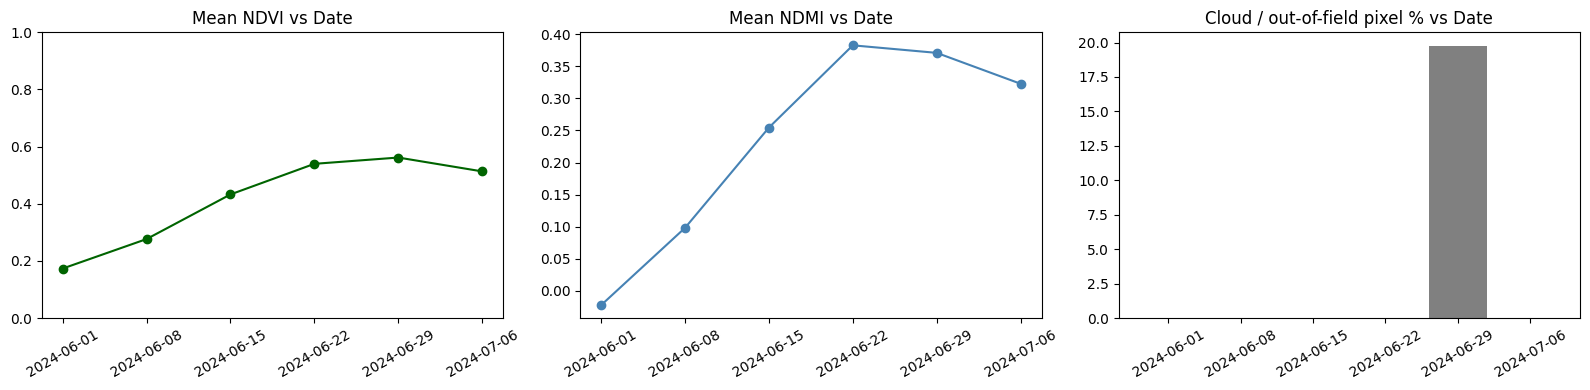

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(eda_df["date"], eda_df["mean_ndvi"], marker="o", color="darkgreen")
axes[0].set_title("Mean NDVI vs Date"); axes[0].set_ylim(0, 1); axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(eda_df["date"], eda_df["mean_ndmi"], marker="o", color="steelblue")
axes[1].set_title("Mean NDMI vs Date"); axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(eda_df["date"], 100 - eda_df["valid_pixel_pct"], color="gray")
axes[2].set_title("Cloud / out-of-field pixel % vs Date"); axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### What to look for
- NDVI should rise through canopy closure (June) then taper — matches the synthetic phenology curve baked into this data.
- The June 29 cloud spike should show up clearly in the **third panel** (cloud %) without dragging mean NDVI down artificially — that's the masking working correctly.
- The July 6 stress patch should show up as a genuine dip in mean NDVI/NDRE, *not* accompanied by a cloud-% spike — that's the signal the model in `05_cnn_lstm.ipynb` needs to learn to catch.

### Next
`clean_channels_<date>.npy` (15, H, W) files replace the old raw `patches_<date>.npy` as the input to patch/sequence extraction. Update `src/dataset.py`'s patch-building step to load from `clean_channels_*.npy` instead of calling `build_processed_field` directly on raw bands.